In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import skimage.transform as transform
from tqdm import tqdm

In [2]:
def convert_string_field_to_float(field, mesh_shape = (100, 60, 60)):
    x_dim = mesh_shape[0]
    y_dim = mesh_shape[1]
    z_dim = mesh_shape[2]
    return np.array(field[1:].reshape(x_dim-1, y_dim, z_dim), dtype = 'float')

def read_npz_file(fname, *fields, debug = False):
    power = fname.split('power_')[1].split('_velocity')[0]
    velocity = fname.split('velocity_')[1].split('_')[0]#.split('/data')[0]
    timestep = fname.split('data')[1].split('.npz')[0]
    npyfile = np.load(fname, allow_pickle = True)
    if debug:
        print(npyfile.files)
    field_dict = {}
    for field in fields:
    
        field_3d= npyfile[field]  
        field_dict[field] = convert_string_field_to_float(field_3d, mesh_shape = field_3d.shape).astype(float)
    return power, velocity, timestep, field_dict

def get_temperature_from_npz_file(npz_file):
    power = npz_file.split('power_')[1].split('_velocity')[0]
    velocity = npz_file.split('velocity_')[1].split('/data')[0]
    fields = np.load(npz_file, allow_pickle = True)
    temperature = convert_string_field_to_float(fields['temperature'], mesh_shape = (199, 61,62))
    return temperature
def plot_field(field, field_name = ''):
    plt.imshow(field[:, field.shape[1]//2, :].T, origin = 'lower')
    plt.title(field_name)
    plt.colorbar()
    plt.show() 

In [3]:
HR_PARENT_DIRECTORY ='../datasets/matdes_revision/nominal/hr/'
LR_PARENT_DIRECTORY = '../datasets/matdes_revision/nominal/lr/'
LR_TARGET_DIRECTORY = '../datasets/matdes_revision/nominal/low_res_processed/'
HR_TARGET_DIRECTORY =  '../datasets/matdes_revision/nominal/high_res_processed/'
hrmesh = 10
lrmesh = 20
pdir = HR_PARENT_DIRECTORY 
print(os.listdir(pdir))
highresdirectories = [directory for directory in os.listdir(pdir) if os.path.isdir(os.path.join(pdir, directory))]
print(highresdirectories, 'here')
highresdirectories  = [directory for directory in highresdirectories if directory.find('melt')>0]
print(highresdirectories, 'here')
compare_highres  = [directory.split('myoutput.melt_')[1] for directory in highresdirectories if directory.find('melt')>0]
print(compare_highres)
lowrespdir = LR_PARENT_DIRECTORY
lowresdirectories = [directory for directory in os.listdir(lowrespdir) if os.path.isdir(os.path.join(lowrespdir, directory))]
lowresdirectories = [directory for directory in lowresdirectories if directory.find('melt')>0]
compare_lowres = [directory.split('myoutput.melt_')[1] for directory in lowresdirectories if directory.find('melt')>0 ]#[directory.split('myoutput.melt')[1] for directory in lowresdirectories]
print(compare_lowres, 'here')
print(compare_highres, 'hr')


highres = True
lowres = False


current_dirs = highresdirectories
check_dirs = compare_highres
verify_dirs = compare_lowres
img_size = 20*(int(np.round(20/hrmesh)))


['myoutput.melt_power_300_velocity_1000_nominal_dir.zip', 'myoutput.melt_power_300_velocity_1000_nominal']
['myoutput.melt_power_300_velocity_1000_nominal'] here
['myoutput.melt_power_300_velocity_1000_nominal'] here
['power_300_velocity_1000_nominal']
['power_300_velocity_1000_nominal'] here
['power_300_velocity_1000_nominal'] hr


Now processing: myoutput.melt_power_300_velocity_1000_nominal
Processing 101 timesteps


  0%|          | 0/100 [00:00<?, ?it/s]

(145, 32, 1)
(30, 32, 1)


ValueError: x and y must have same first dimension, but have shapes (40,) and (60,)

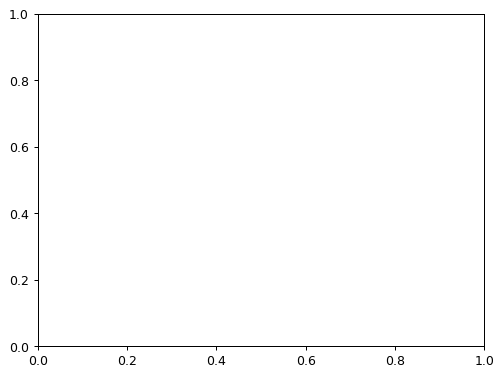

In [6]:
scale =int(np.round(lrmesh/hrmesh))
plt.rcParams['axes.facecolor']='white'
plt.rcParams['savefig.facecolor']='white'

plot = True
debug = False
lrtextdir = LR_TARGET_DIRECTORY
os.makedirs(lrtextdir, exist_ok=True)
textdir = HR_TARGET_DIRECTORY
padsize = img_size//2
pad_values = {'vx': 0, 'vy':0, 'vz':0, 'temperature':293, 'pressure': 1000000, 'liqlabel':0}
axis_lim_min= {'vx': -30, 'vy':-30, 'vz':-30, 'temperature':293, 'pressure': 900000, 'liqlabel':0}
axis_lim_max= {'vx': 30, 'vy':30, 'vz':30, 'temperature':5000, 'pressure': 4*1000000, 'liqlabel':1}
titles= {'vx': r"$v_x$ [cm/s]", 'vy':r"$v_y$ [cm/s]", 'vz':r"$v_z$ [cm/s]", 'temperature':"T [K]", 'pressure': "P [Pa]", 'liqlabel':"Liquid Volume Fraction"}


for idx,direct in enumerate([dir for dir in current_dirs if check_dirs[current_dirs.index(dir)] in verify_dirs]):
    directory_used = os.path.join(pdir, direct)
    padsize = img_size//2
    power = direct.split('power_')[1].split('_velocity')[0]
    velocity = direct.split('velocity_')[1].split('_')[0]
    print("Now processing: " + str(direct))
    num_timesteps = len(glob.glob(directory_used + '/data*.npz'))
    print(f'Processing {num_timesteps} timesteps')
    for i in tqdm(range(1,num_timesteps)):
        profiles = []
        directory = pdir + direct
        if highres:
            low_res_dir = lowrespdir+lowresdirectories[verify_dirs.index(check_dirs[current_dirs.index(direct)])]
        try:

            field_names = ['temperature']
            power, velocity, timestep, field_dict = read_npz_file(directory + '/data' + '{:02}'.format(i) + '.npz',*field_names)
            power, velocity, timestep, low_res_field_dict = read_npz_file(low_res_dir + '/data' + '{:02}'.format(i) + '.npz',*field_names)
            os.makedirs('fieldfiguresp{}v{}'.format(power, velocity), exist_ok = True)
            if debug:
                print(field_dict.keys)
                plot_field(field_dict['temperature'])
                plot_field(low_res_field_dict['temperature'])

            multi_field_frame = np.stack(list(field_dict.values()), axis = -1)
            multi_field_lr_frame = np.stack(list(low_res_field_dict.values()), axis = -1)
            multi_field_keys = list(field_dict.keys())
            key_string = ''.join(multi_field_keys)

            
        except OSError as e:
            print(e)
            print('skipping, ', direct)
            continue

        hres_point = 10 + (int(velocity)/2000)*(i-1)
       
        hr_theta_pad = np.zeros((multi_field_frame.shape[0]+2*padsize, multi_field_frame.shape[2],multi_field_frame.shape[-1]))
        lr_theta_pad = np.zeros((multi_field_lr_frame.shape[0]+2*padsize//scale, multi_field_lr_frame.shape[2],multi_field_lr_frame.shape[-1]))

        for field_idx, field_key in zip(np.arange(multi_field_frame.shape[-1]), multi_field_keys):
            constant_value = pad_values[field_key]
            if debug:
                print(field_idx, field_key, constant_value)
            hr_theta_pad[:,:, field_idx] = np.copy(np.pad(multi_field_frame[:, multi_field_frame.shape[1]//2,:, field_idx], ((padsize, padsize), (0, 0)), mode = 'constant', constant_values = constant_value))
            lr_theta_pad[:,:, field_idx] = np.copy(np.pad(multi_field_lr_frame[:, multi_field_lr_frame.shape[1]//2,:, field_idx], ((padsize//scale, padsize//scale), (0, 0)), mode = 'constant', constant_values = constant_value))
            if debug:
                plt.imshow(hr_theta_pad[:,:,field_idx].T, origin = 'lower')
                plt.colorbar()
                plt.show()
                plt.imshow(lr_theta_pad[:,:,field_idx].T, origin = 'lower')
                plt.colorbar()
                plt.show()

        idx_max = int(10+  (int(velocity)/2000)*(i-1)) + padsize 
        low_res_idx_max = int(int(np.round(10/scale))  + (int(velocity)/2000/scale)*(i-1)) + np.round(int(padsize/scale))
        print(lr_theta_pad.shape)
        lr_theta_cropped = lr_theta_pad[low_res_idx_max-15*(20//lrmesh): low_res_idx_max+15*(20//lrmesh),:60]
        print(lr_theta_cropped.shape)
        hr_theta_cropped = hr_theta_pad[int(np.round(idx_max))-15*(20//hrmesh): int(np.round(idx_max))+15*(20//hrmesh), 2:]
        # break
        if plot:
            for field_idx, field_key in zip(np.arange(multi_field_frame.shape[-1]), multi_field_keys):
                plt.figure(dpi = 90)
                
                plt.step(hrmesh*np.arange(20*(int(np.round(20/hrmesh)))), hr_theta_cropped[:,-10,field_idx], label = 'High Res')
                plt.step(lrmesh*np.arange(20*(int(np.round(20/lrmesh)))), lr_theta_cropped[:,-5,field_idx], label = 'Low Res')
                print(low_res_idx_max, idx_max/4)
                plt.ylim([ axis_lim_min[field_key], axis_lim_max[field_key]*2])
                plt.xlabel(r'x [$\mu m$]')
                plt.ylabel(titles[field_key])
                plt.title('t = {} s, P = {} W, V = {} mm/s'.format(0.5*i/100, power, velocity))

                plt.legend()
                plt.show()
                plt.savefig('fieldfiguresp{}v{}/'.format(power, velocity) + field_key + 'newlineplot{:04}.png'.format(idx))
                plt.clf()
                plt.figure(dpi = 90)
                # print(np.arange(20*(int(np.round(20/hrmesh)))),  hr_theta_cropped[:,:,field_idx].shape)
                plt.pcolormesh(hrmesh*np.arange(20*(int(np.round(20/hrmesh)))), hrmesh*np.arange(20*(int(np.round(20/hrmesh)))), hr_theta_cropped[:,:,field_idx].T, cmap = 'jet', vmin = axis_lim_min[field_key], vmax = axis_lim_max[field_key])
                plt.xlabel(r'x [$\mu m$]')
                plt.ylabel(r'z [$\mu m$]')
                
                clb = plt.colorbar()
                clb.ax.set_title(titles[field_key])
                if field_key == 'temperature':
                    plt.contour(hrmesh*np.arange(20*(int(np.round(20/hrmesh)))), hrmesh*np.arange(20*(int(np.round(20/hrmesh)))), hr_theta_cropped[:,:,field_idx].T, levels = [1900], colors = 'r')
                    
                    plt.contour(lrmesh*np.arange(20*(int(np.round(20/lrmesh)))), lrmesh*np.arange(20*(int(np.round(20/lrmesh)))), lr_theta_cropped[:,:,field_idx].T, levels = [1900], colors = 'k')
                plt.title('t = {} s, P = {} W, V = {} mm/s'.format(0.5*i/100, power, velocity))
                # plt.show()
                plt.savefig('fieldfiguresp{}v{}/'.format(power, velocity) + field_key + 'newlinecomparisoncontour{:04}.png'.format(i))
                plt.clf()
                plt.close('all')
                plt.figure(dpi = 90)
                plt.pcolormesh(lrmesh*np.arange(20*(int(np.round(20/lrmesh)))), lrmesh*np.arange(20*(int(np.round(20/lrmesh)))), lr_theta_cropped[:,:,field_idx].T, cmap = 'jet', vmin = axis_lim_min[field_key], vmax = axis_lim_max[field_key])
                plt.xlabel(r'x [$\mu m$]')
                plt.ylabel(r'z [$\mu m$]')
                clb = plt.colorbar()
                clb.ax.set_title(titles[field_key])
                plt.title('t = {} s, P = {} W, V = {} mm/s'.format(0.5*i/100, power, velocity))
                plt.show()
                plt.savefig('fieldfiguresp{}v{}/'.format(power, velocity) + field_key + 'newcentercomparisoncontour{:04}.png'.format(i))
                plt.clf()
                plt.close('all')
        # break
        os.makedirs(textdir + '/croptempsquare/' + 'power'+ str(power)+'velocity'+str(velocity)+'/', exist_ok=True)
        os.makedirs(lrtextdir + '/croptempsquare/' + 'power'+ str(power)+'velocity'+str(velocity)+'/', exist_ok = True)
        os.makedirs(lrtextdir + '/croptempsquare_{}_upscale/'.format(hrmesh) + 'power'+ str(power)+'velocity'+str(velocity)+'/', exist_ok = True)
        np.save(textdir + '/croptempsquare/' + 'power'+ str(power)+'velocity'+str(velocity)+'/_'+ str(i+1000) + '.npy', hr_theta_cropped)
        np.save(lrtextdir + '/croptempsquare/' + 'power'+ str(power)+'velocity'+str(velocity)+'/_'+ str(i+1000) + '.npy', lr_theta_cropped)
        lrupscale = transform.resize(lr_theta_cropped, (hr_theta_cropped.shape))
        np.save(lrtextdir + '/croptempsquare_{}_upscale/'.format(hrmesh) + 'power'+ str(power)+'velocity'+str(velocity)+'/_'+ str(i+1000) + '.npy', lrupscale)
        # break
    # break


In [41]:
HR_PARENT_DIRECTORY ='../datasets/matdes_revision/hatch_spacing/hr/'
LR_PARENT_DIRECTORY = '../datasets/matdes_revision/hatch_spacing/lr/'
LR_TARGET_DIRECTORY = '../datasets/matdes_revision/hatch_spacing/low_res_processed/'
HR_TARGET_DIRECTORY =  '../datasets/matdes_revision/hatch_spacing/high_res_processed/'
hrmesh = 10
lrmesh = 20
pdir = HR_PARENT_DIRECTORY 
print(os.listdir(pdir))
highresdirectories = [directory for directory in os.listdir(pdir) if os.path.isdir(os.path.join(pdir, directory))]
print(highresdirectories, 'here')
highresdirectories  = [directory for directory in highresdirectories if directory.find('melt')>0]
print(highresdirectories, 'here')
compare_highres  = [directory.split('myoutput.melt_')[1] for directory in highresdirectories if directory.find('melt')>0]
print(compare_highres)
lowrespdir = LR_PARENT_DIRECTORY
lowresdirectories = [directory for directory in os.listdir(lowrespdir) if os.path.isdir(os.path.join(lowrespdir, directory))]
lowresdirectories = [directory for directory in lowresdirectories if directory.find('melt')>0]
compare_lowres = [directory.split('myoutput.melt_')[1] for directory in lowresdirectories if directory.find('melt')>0 ]#[directory.split('myoutput.melt')[1] for directory in lowresdirectories]
print(compare_lowres, 'here')
print(compare_highres, 'hr')


highres = True
lowres = False


current_dirs = highresdirectories
check_dirs = compare_highres
verify_dirs = compare_lowres
img_size = 20*(int(np.round(20/hrmesh)))


['myoutput.melt_power_300_velocity_1000_hatch_spacing_10_dir.zip', 'old', 'myoutput.melt_power_300_velocity_1000_hatch_spacing']
['old', 'myoutput.melt_power_300_velocity_1000_hatch_spacing'] here
['myoutput.melt_power_300_velocity_1000_hatch_spacing'] here
['power_300_velocity_1000_hatch_spacing']
['power_300_velocity_1000_hatch_spacing'] here
['power_300_velocity_1000_hatch_spacing'] hr


In [42]:
len(highresdirectories[0])

51

In [43]:
scale =int(np.round(lrmesh/hrmesh))
plt.rcParams['axes.facecolor']='white'
plt.rcParams['savefig.facecolor']='white'

plot = False
debug = False
lrtextdir = LR_TARGET_DIRECTORY
os.makedirs(lrtextdir, exist_ok=True)
textdir = HR_TARGET_DIRECTORY
padsize = img_size//2
pad_values = {'vx': 0, 'vy':0, 'vz':0, 'temperature':293, 'pressure': 1000000, 'liqlabel':0}
axis_lim_min= {'vx': -30, 'vy':-30, 'vz':-30, 'temperature':293, 'pressure': 900000, 'liqlabel':0}
axis_lim_max= {'vx': 30, 'vy':30, 'vz':30, 'temperature':5000, 'pressure': 4*1000000, 'liqlabel':1}
titles= {'vx': r"$v_x$ [cm/s]", 'vy':r"$v_y$ [cm/s]", 'vz':r"$v_z$ [cm/s]", 'temperature':"T [K]", 'pressure': "P [Pa]", 'liqlabel':"Liquid Volume Fraction"}


for idx,direct in enumerate([dir for dir in current_dirs if check_dirs[current_dirs.index(dir)] in verify_dirs]):
    directory_used = os.path.join(pdir, direct)
    padsize = img_size//2
    power = direct.split('power_')[1].split('_velocity')[0]
    velocity = direct.split('velocity_')[1].split('_')[0]
    print("Now processing: " + str(direct))
    num_timesteps = len(glob.glob(directory_used + '/data*.npz'))
    print(f'Processing {num_timesteps} timesteps')
    for i in tqdm(range(1,num_timesteps)):
        profiles = []
        directory = pdir + direct
        if highres:
            low_res_dir = lowrespdir+lowresdirectories[verify_dirs.index(check_dirs[current_dirs.index(direct)])]
        try:

            field_names = ['temperature']
            power, velocity, timestep, field_dict = read_npz_file(directory + '/data' + '{:02}'.format(i) + '.npz',*field_names)
            power, velocity, timestep, low_res_field_dict = read_npz_file(low_res_dir + '/data' + '{:02}'.format(i) + '.npz',*field_names)
            os.makedirs('fieldfiguresp{}v{}'.format(power, velocity), exist_ok = True)
            if debug:
                print(field_dict.keys)
                plot_field(field_dict['temperature'])
                plot_field(low_res_field_dict['temperature'])

            multi_field_frame = np.stack(list(field_dict.values()), axis = -1)
            multi_field_lr_frame = np.stack(list(low_res_field_dict.values()), axis = -1)
            multi_field_keys = list(field_dict.keys())
            key_string = ''.join(multi_field_keys)

            
        except OSError as e:
            print(e)
            print('skipping, ', direct)
            continue

        hres_point = 10 + (int(velocity)/2000)*(i-1)
       
        hr_theta_pad = np.zeros((multi_field_frame.shape[0]+2*padsize, multi_field_frame.shape[2],multi_field_frame.shape[-1]))
        lr_theta_pad = np.zeros((multi_field_lr_frame.shape[0]+2*padsize//scale, multi_field_lr_frame.shape[2],multi_field_lr_frame.shape[-1]))

        for field_idx, field_key in zip(np.arange(multi_field_frame.shape[-1]), multi_field_keys):
            constant_value = pad_values[field_key]
            if debug:
                print(field_idx, field_key, constant_value)
            hr_theta_pad[:,:, field_idx] = np.copy(np.pad(multi_field_frame[:, multi_field_frame.shape[1]//2,:, field_idx], ((padsize, padsize), (0, 0)), mode = 'constant', constant_values = constant_value))
            lr_theta_pad[:,:, field_idx] = np.copy(np.pad(multi_field_lr_frame[:, multi_field_lr_frame.shape[1]//2,:, field_idx], ((padsize//scale, padsize//scale), (0, 0)), mode = 'constant', constant_values = constant_value))
            if debug:
                plt.imshow(hr_theta_pad[:,:,field_idx].T, origin = 'lower')
                plt.colorbar()
                plt.show()
                plt.imshow(lr_theta_pad[:,:,field_idx].T, origin = 'lower')
                plt.colorbar()
                plt.show()

        idx_max = int(10+  (int(velocity)/2000)*(i-1)) + padsize 
        low_res_idx_max = int(int(np.round(10/scale))  + (int(velocity)/2000/scale)*(i-1)) + np.round(int(padsize/scale))
        lr_theta_cropped = lr_theta_pad[low_res_idx_max-15*(20//lrmesh): low_res_idx_max+15*(20//lrmesh),:60]
        hr_theta_cropped = hr_theta_pad[int(np.round(idx_max))-15*(20//hrmesh): int(np.round(idx_max))+15*(20//hrmesh), 2:]
  
        if plot:
            for field_idx, field_key in zip(np.arange(multi_field_frame.shape[-1]), multi_field_keys):
                plt.figure(dpi = 90)
                
                plt.step(hrmesh*np.arange(20*(int(np.round(20/hrmesh)))), hr_theta_cropped[:,-10,field_idx], label = 'High Res')
                plt.step(lrmesh*np.arange(20*(int(np.round(20/lrmesh)))), lr_theta_cropped[:,-5,field_idx], label = 'Low Res')
                print(low_res_idx_max, idx_max/4)
                plt.ylim([ axis_lim_min[field_key], axis_lim_max[field_key]*2])
                plt.xlabel(r'x [$\mu m$]')
                plt.ylabel(titles[field_key])
                plt.title('t = {} s, P = {} W, V = {} mm/s'.format(0.5*i/100, power, velocity))

                plt.legend()
                plt.show()
                plt.savefig('fieldfiguresp{}v{}/'.format(power, velocity) + field_key + 'newlineplot{:04}.png'.format(idx))
                plt.clf()
                plt.figure(dpi = 90)
                # print(np.arange(20*(int(np.round(20/hrmesh)))),  hr_theta_cropped[:,:,field_idx].shape)
                plt.pcolormesh(hrmesh*np.arange(20*(int(np.round(20/hrmesh)))), hrmesh*np.arange(20*(int(np.round(20/hrmesh)))), hr_theta_cropped[:,:,field_idx].T, cmap = 'jet', vmin = axis_lim_min[field_key], vmax = axis_lim_max[field_key])
                plt.xlabel(r'x [$\mu m$]')
                plt.ylabel(r'z [$\mu m$]')
                
                clb = plt.colorbar()
                clb.ax.set_title(titles[field_key])
                if field_key == 'temperature':
                    plt.contour(hrmesh*np.arange(20*(int(np.round(20/hrmesh)))), hrmesh*np.arange(20*(int(np.round(20/hrmesh)))), hr_theta_cropped[:,:,field_idx].T, levels = [1900], colors = 'r')
                    
                    plt.contour(lrmesh*np.arange(20*(int(np.round(20/lrmesh)))), lrmesh*np.arange(20*(int(np.round(20/lrmesh)))), lr_theta_cropped[:,:,field_idx].T, levels = [1900], colors = 'k')
                plt.title('t = {} s, P = {} W, V = {} mm/s'.format(0.5*i/100, power, velocity))
                # plt.show()
                plt.savefig('fieldfiguresp{}v{}/'.format(power, velocity) + field_key + 'newlinecomparisoncontour{:04}.png'.format(i))
                plt.clf()
                plt.close('all')
                plt.figure(dpi = 90)
                plt.pcolormesh(lrmesh*np.arange(20*(int(np.round(20/lrmesh)))), lrmesh*np.arange(20*(int(np.round(20/lrmesh)))), lr_theta_cropped[:,:,field_idx].T, cmap = 'jet', vmin = axis_lim_min[field_key], vmax = axis_lim_max[field_key])
                plt.xlabel(r'x [$\mu m$]')
                plt.ylabel(r'z [$\mu m$]')
                clb = plt.colorbar()
                clb.ax.set_title(titles[field_key])
                plt.title('t = {} s, P = {} W, V = {} mm/s'.format(0.5*i/100, power, velocity))
                plt.show()
                plt.savefig('fieldfiguresp{}v{}/'.format(power, velocity) + field_key + 'newcentercomparisoncontour{:04}.png'.format(i))
                plt.clf()
                plt.close('all')
        os.makedirs(textdir + '/croptempsquare/' + 'power'+ str(power)+'velocity'+str(velocity)+'/', exist_ok=True)
        os.makedirs(lrtextdir + '/croptempsquare/' + 'power'+ str(power)+'velocity'+str(velocity)+'/', exist_ok = True)
        os.makedirs(lrtextdir + '/croptempsquare_{}_upscale/'.format(hrmesh) + 'power'+ str(power)+'velocity'+str(velocity)+'/', exist_ok = True)
        # np.save(textdir + '/croptempsquare/' + 'power'+ str(power)+'velocity'+str(velocity)+'/_'+ str(i+1000) + '.npy', hr_theta_cropped)
        # np.save(lrtextdir + '/croptempsquare/' + 'power'+ str(power)+'velocity'+str(velocity)+'/_'+ str(i+1000) + '.npy', lr_theta_cropped)
        lrupscale = transform.resize(lr_theta_cropped, (hr_theta_cropped.shape))
        # np.save(lrtextdir + '/croptempsquare_{}_upscale/'.format(hrmesh) + 'power'+ str(power)+'velocity'+str(velocity)+'/_'+ str(i+1000) + '.npy', lrupscale)
        # break
    # break


Now processing: myoutput.melt_power_300_velocity_1000_hatch_spacing
Processing 101 timesteps


100%|██████████| 100/100 [00:52<00:00,  1.89it/s]


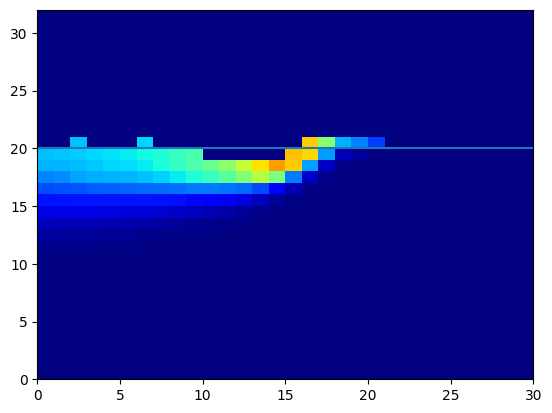

In [39]:
plt.pcolormesh(lr_theta_cropped[:,:,field_idx].T, cmap = 'jet', vmin = axis_lim_min[field_key], vmax = axis_lim_max[field_key])
plt.axhline(20)

(60, 60)

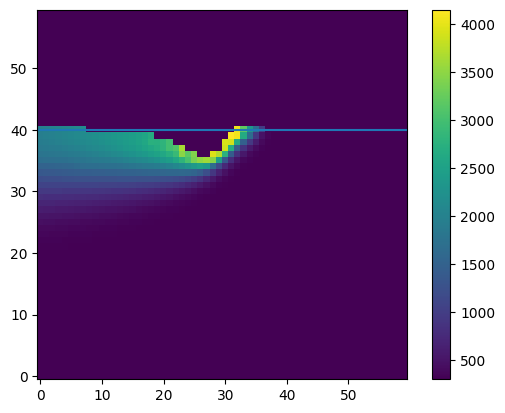

In [40]:
# hr_theta_cropped.shape
plt.imshow(hr_theta_pad[int(np.round(idx_max))-15*(20//hrmesh): int(np.round(idx_max))+15*(20//hrmesh), :60].T[0], origin= 'lower')
plt.axhline(40)
# plt.axhline(42)

plt.colorbar()
hr_theta_pad[int(np.round(idx_max))-15*(20//hrmesh): int(np.round(idx_max))+15*(20//hrmesh), 2:].T[0].shape

In [48]:
# lr_theta_pad[low_res_idx_max-15*(20//lrmesh): low_res_idx_max+15*(20//lrmesh),:30].shape
hr_theta_pad[int(np.round(idx_max))-15*(20//hrmesh): int(np.round(idx_max))+15*(20//hrmesh), :60].shape

(60, 60, 1)

In [19]:
unique_pvs = os.listdir(os.path.join(LR_TARGET_DIRECTORY, 'croptempsquare'))
for pv in unique_pvs:
    timesteps = sorted(os.listdir(os.path.join(LR_TARGET_DIRECTORY, 'croptempsquare', pv)))
    print(timesteps)
    

['_1001.npy', '_1002.npy', '_1003.npy', '_1004.npy', '_1005.npy', '_1006.npy', '_1007.npy', '_1008.npy', '_1009.npy', '_1010.npy', '_1011.npy', '_1012.npy', '_1013.npy', '_1014.npy', '_1015.npy', '_1016.npy', '_1017.npy', '_1018.npy', '_1019.npy', '_1020.npy', '_1021.npy', '_1022.npy', '_1023.npy', '_1024.npy', '_1025.npy', '_1026.npy', '_1027.npy', '_1028.npy', '_1029.npy', '_1030.npy', '_1031.npy', '_1032.npy', '_1033.npy', '_1034.npy', '_1035.npy', '_1036.npy', '_1037.npy', '_1038.npy', '_1039.npy', '_1040.npy', '_1041.npy', '_1042.npy', '_1043.npy', '_1044.npy', '_1045.npy', '_1046.npy', '_1047.npy', '_1048.npy', '_1049.npy', '_1050.npy', '_1051.npy', '_1052.npy', '_1053.npy', '_1054.npy', '_1055.npy', '_1056.npy', '_1057.npy', '_1058.npy', '_1059.npy', '_1060.npy', '_1061.npy', '_1062.npy', '_1063.npy', '_1064.npy', '_1065.npy', '_1066.npy', '_1067.npy', '_1068.npy', '_1069.npy', '_1070.npy', '_1071.npy', '_1072.npy', '_1073.npy', '_1074.npy', '_1075.npy', '_1076.npy', '_1077.npy'

In [20]:
import sys
import numpy as np
from pylab import gca
import numpy as np
import math
from tqdm import tqdm
import torch
import torchvision
import torch.nn as nn
from torch.utils import data
import torch.nn.functional as F
from torchvision import transforms
from torchvision.utils import save_image
from torchvision.datasets import MNIST
import torchvision.transforms.functional as TF
from torch.optim import lr_scheduler
import time
import os
from skimage.metrics import structural_similarity as ssim_id
from diffusionsr.analysis.plotting_functions import frame_tick, legend
import cv2
import os
from torchvision import transforms
from torch.utils.data import DataLoader
from pathlib import Path
from torch.utils.data import Dataset
import pdb
from PIL import Image
import matplotlib.pyplot as plt 
# print(os.listdir('.'))
from diffusionsr.datasets.dataset import SimulationXZDataset
import wandb

# from datasets.dataset import TemperatureXZDataset
from diffusionsr.runners.train_diffusion import forwardpass
from diffusionsr.analysis.analysis_functions import predict_lrenc, predict_mobilenet, predict_ddim_diffusion,predict_modified_diffusion, predict_diffusion, plot_images, get_profile, load_mobilenet, load_encoder, load_diffusion, PSNR, SSIM, multifield_plot_images
from diffusionsr.models.diffusion_model import Unet
from diffusionsr.models.lr_encoder_model import rrdbnet_encoder as rrdbnet_x4

In [21]:
wandb_id = 'p4c77tn2'
api  = wandb.Api()
run = api.run(f'fogoke/Flow3D_SuperResolution/{wandb_id}')
config = run.config


In [22]:
config


{'gpu': '4',
 'config': 'ss316l_updated_simulations_longer.yml',
 'epochs': 1000,
 'fields': 'temperature',
 'n_steps': '1',
 'encoding': True,
 'schedule': 'linear',
 'modeltype': 'diffusion',
 'timesteps': 1000,
 'batch_size': 32,
 'restart_dir': '/home/oogoke/DiffusionSR/runs/direct/diffusionimplicitencoded/2023_10_07_09_51_27_restart/standardize/n_steps_1',
 'root_folder': '/home/oogoke/DiffusionSR/datasets/expanded_ss316l_all_laser_velocity_xz_cross_section_data_expanded_frame',
 'conditioning': 'implicit',
 'learning_rate': '5e-5',
 'residual_flag': False,
 'use_pretrained': True,
 'downscale_method': 'direct',
 'normalize_method': 'standardize',
 'encoder_results_dir': '/home/oogoke/DiffusionSR/runs/direct/encoder/2023_10_06_17_48_51/standardize/n_steps_1'}